# The goal
Predicting 30-Day Hospital Readmission Risk Using Machine Learning

# Team Members
(Thelma , Tino , Willie )

# Project Overview

Hospital readmissions are a major challenge for healthcare systems. Patients who return to the hospital shortly after discharge often indicate incomplete recovery, complications, or insufficient follow-up care. In particular, diabetic patients have a higher risk of readmission due to the complexity of managing their condition.

The goal of this project is to develop a machine learning model that can predict whether a diabetic patient will be readmitted to the hospital within **30 days of discharge**.

By identifying high-risk patients early, hospitals can implement targeted interventions such as improved discharge planning, follow-up appointments, and patient education.

This project follows the full machine learning lifecycle:
- Problem definition
- Data understanding
- Exploratory data analysis
- Data preprocessing
- Model development
- Model evaluation
- Interpretation of results

# Dataset Overview

The dataset used in this project is the Diabetes 130-US Hospitals dataset from the UCI Machine Learning Repository.

It contains records of hospital encounters for diabetic patients between 1999 and 2008.

Each row represents a hospital visit and includes patient demographics, medical procedures, medications, and hospital stay information.

The dataset will be used to predict whether a patient will be readmitted to the hospital within 30 days after discharge.

# Stakeholders

The primary stakeholders include:

- Hospital administrators
- Clinical care teams
- Discharge planning teams
- Healthcare insurers

These stakeholders are interested in reducing avoidable hospital readmissions because they increase healthcare costs and may indicate gaps in patient care.

# Machine Learning Task

This project is formulated as a **binary classification problem**.

The model will predict whether a patient will be readmitted within 30 days after discharge.

Target variable:

- **1** → Readmitted within 30 days
- **0** → Not readmitted within 30 days

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [37]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data  
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features # Input features (patient info, medications, hospital details)
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets # Target variable (readmission status)
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# view variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

C:\Users\munyu\anaconda3\New folder\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

# Feature and Target Separation

The dataset was separated into:

X → input features describing the patient encounter  
y → the target variable indicating whether the patient was readmitted.

This separation follows standard supervised learning practice where the model learns to map features (X) to the target variable (y).

# dataset structure 

In [21]:
# Dataset shape
X.shape 

(101766, 47)

In [22]:
#Column names
X.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')

In [23]:
# understanding data types of varibales the dataset
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

#we have 
11 numeric features
36 categorical features
later we need to scale numeric variables
encode categorical variables which shows we understand feature preprocessing

In [13]:
# it helps to identify need for scaling
X.describe() #Shows statistics for numeric columns:
# Outlier Detection: Large gaps between the 75% mark 
# and the max value indicate potential anomalies that could bias your model.

#Z-score can be applied if my data is normally distributed 
# or we can use this 
# Calculate IQR: IQR = Q3 - Q1
# Define Bounds:Lower Bound = Q1 - 1.5*  IQR 
# Upper Bound = Q3 + 1.5 * IQR
# Action: Data points outside these bounds are flagged as outliers

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [28]:
X['change'].value_counts() # this checks how many patients had medication changes

change
No    54755
Ch    47011
Name: count, dtype: int64

In [29]:
X.isnull().sum()# Shows missing values in each column.

race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

Several variables contain large numbers of missing values.

For example:
- weight is missing for most patients
- A1Cresult and max_glu_serum are missing for many records
- payer_code and medical_specialty also contain substantial missingness

These variables will require careful handling during preprocessing, including potential removal or imputation depending on their predictive value.

In [26]:
# Check for '?' values
(X == "?").sum().sort_values(ascending=False)

race                        0
troglitazone                0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
tolazamide                  0
nateglinide                 0
examide                     0
citoglipton                 0
insulin                     0
glyburide-metformin         0
glipizide-metformin         0
glimepiride-pioglitazone    0
metformin-rosiglitazone     0
metformin-pioglitazone      0
change                      0
chlorpropamide              0
repaglinide                 0
gender                      0
num_procedures              0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_sp

In [27]:
X.sample(5)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
53602,Caucasian,Female,[70-80),NaN,2,3,1,10,MC,NaN,...,No,No,No,No,No,No,No,No,Ch,Yes
28605,AfricanAmerican,Female,[60-70),NaN,2,1,4,5,NaN,Cardiology,...,No,No,No,No,No,No,No,No,No,Yes
86896,Caucasian,Female,[90-100),NaN,2,3,7,1,SP,Emergency/Trauma,...,No,No,No,No,No,No,No,No,No,Yes
98962,Caucasian,Female,[40-50),NaN,1,1,7,6,SP,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
98709,Caucasian,Female,[40-50),NaN,3,1,1,1,CP,Gastroenterology,...,No,No,No,No,No,No,No,No,No,No


# Target Distribution calculates proportion of each class

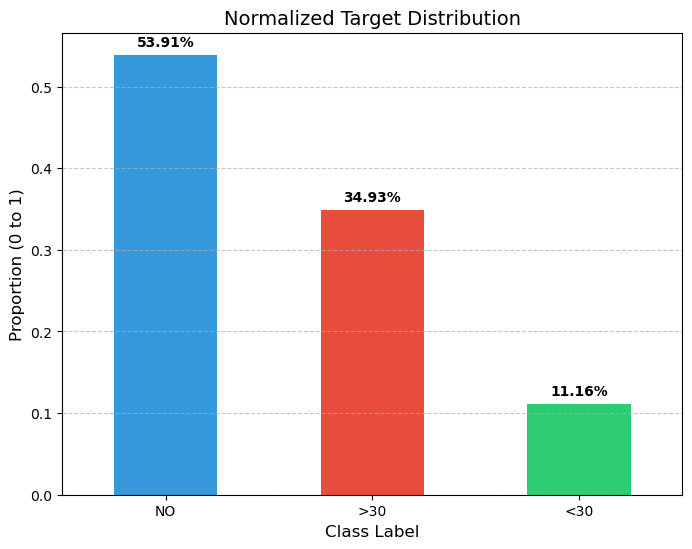

In [34]:
import matplotlib.pyplot as plt
## this crucial for imbalance detection and misclassification of labels
## the baseline model should perform better than 50% since one class is above 50% 
# 1. Calculate the proportions
val_counts = y['readmitted'].value_counts(normalize=True) # to print decimals for normalize option
### Willie change y.value_counts(normalize=True) to  y['readmitted'].value_counts(normalize=True) because y is a dataframe.
# 2. Create the bar plot
plt.figure(figsize=(8, 6))
val_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])

# 3. Format the graph for readability
plt.title('Normalized Target Distribution', fontsize=14)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Proportion (0 to 1)', fontsize=12)
plt.xticks(rotation=0) # Keep labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the exact percentages on top of bars
for i, v in enumerate(val_counts):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

The dataset is moderately imbalanced.

The majority of patients (about 54%) were not readmitted, while only about 11% were readmitted within 30 days.

Because of this imbalance, accuracy alone may not be a sufficient evaluation metric. Metrics such as recall, precision, and F1-score will also be considered during model evaluation.

# Exploratory Data Analysis

In [42]:
df = pd.concat([X, y], axis=1) # first converted to df because some EDA plots need both in one dataframe
df

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,...,No,Up,No,No,No,No,No,Ch,Yes,NO


# Age Distribution

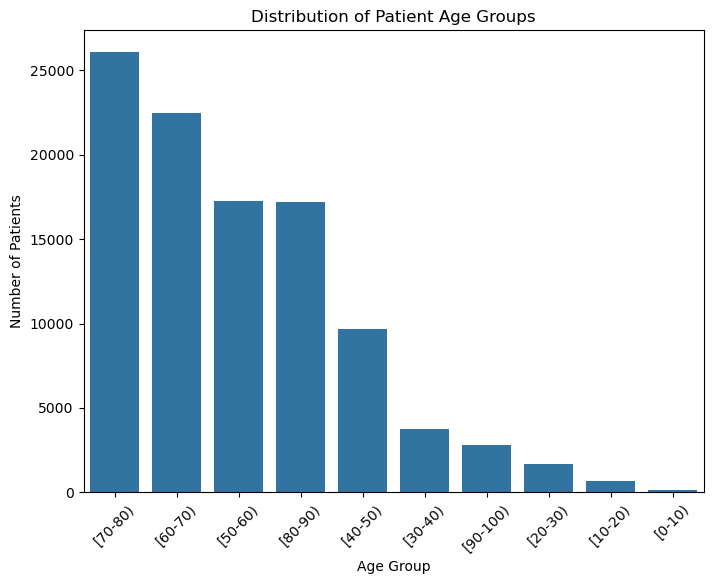

In [51]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="age", order=df["age"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Patient Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

The dataset is dominated by older patients, particularly those aged between 60 and 80 years.

This is expected because complications associated with diabetes become more common with increasing age.

# Hospital Stay Length

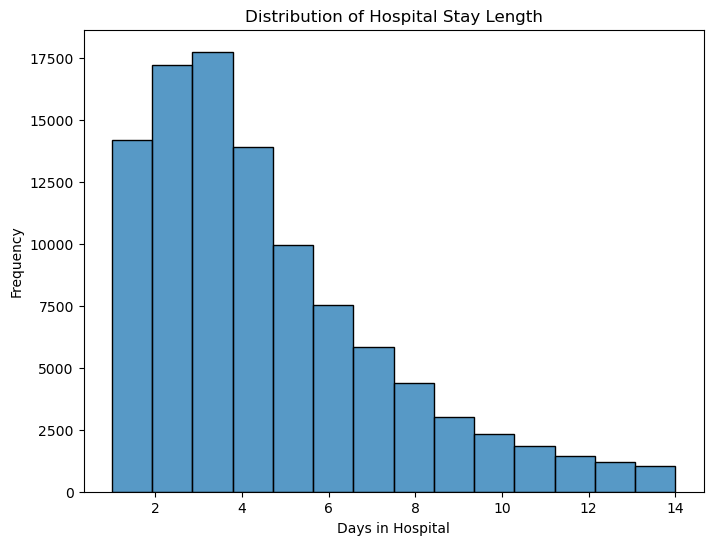

In [45]:
plt.figure(figsize=(8,6))
sns.histplot(df["time_in_hospital"], bins=14, kde=False)
plt.title("Distribution of Hospital Stay Length")
plt.xlabel("Days in Hospital")
plt.ylabel("Frequency")
plt.show()

Most hospital stays are relatively short, typically between 1 and 6 days.

Longer hospital stays may indicate more severe health conditions or complications requiring extended treatment.

# Previous Inpatient Visits vs Readmission

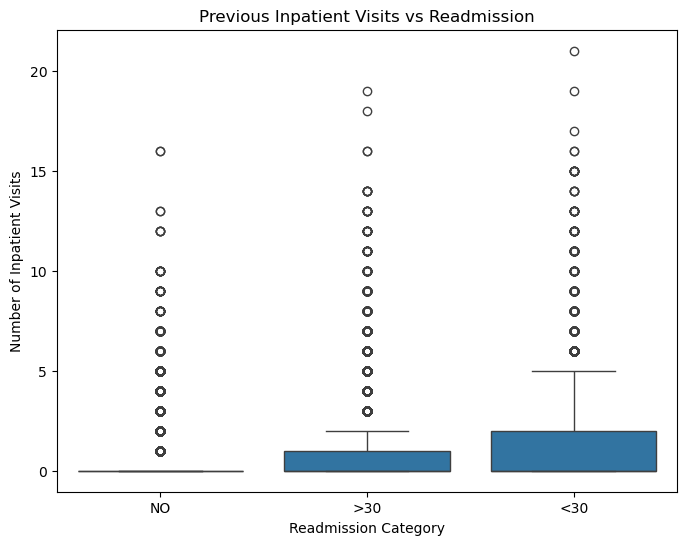

In [46]:
plt.figure(figsize=(8,6))
sns.boxplot(x="readmitted", y="number_inpatient", data=df)
plt.title("Previous Inpatient Visits vs Readmission")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Inpatient Visits")
plt.show()

Patients who were readmitted within 30 days tend to have more previous inpatient visits compared to patients who were not readmitted.

This suggests that prior hospitalization history may be an important predictor of readmission risk. Patients with frequent hospital admissions may have more severe or poorly controlled medical conditions.

# Emergency Visits vs Readmission

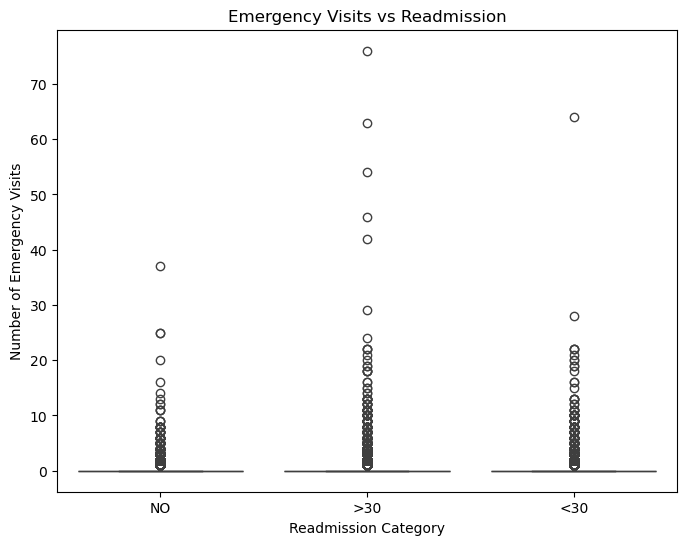

In [47]:
plt.figure(figsize=(8,6))
sns.boxplot(x="readmitted", y="number_emergency", data=df)
plt.title("Emergency Visits vs Readmission")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Emergency Visits")
plt.show()

Patients with higher numbers of emergency visits appear more frequently in the readmission groups.

Frequent emergency visits may indicate unstable health conditions or inadequate outpatient care, which could increase the likelihood of hospital readmission.

# Number of Medications

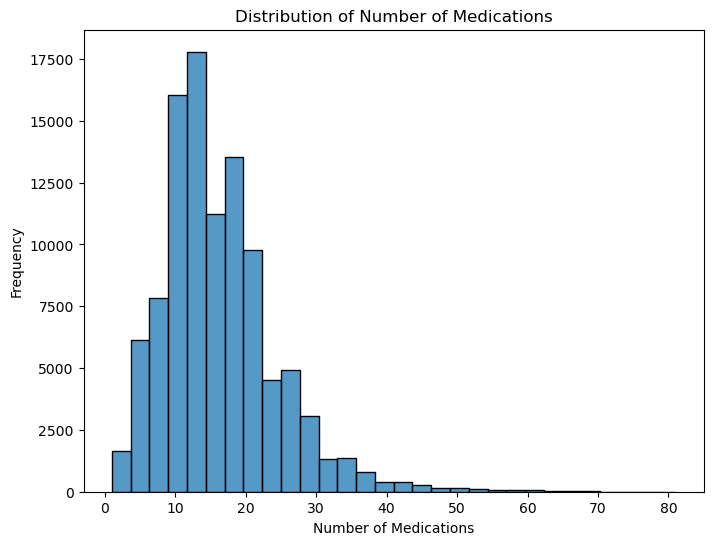

In [48]:
plt.figure(figsize=(8,6))
sns.histplot(df["num_medications"], bins=30)
plt.title("Distribution of Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Frequency")
plt.show()

The distribution of medications is right-skewed, meaning most patients receive a moderate number of medications while a smaller number receive very high medication counts.

Higher medication counts may indicate complex medical conditions requiring multiple treatments.

# Missing Value Visualization

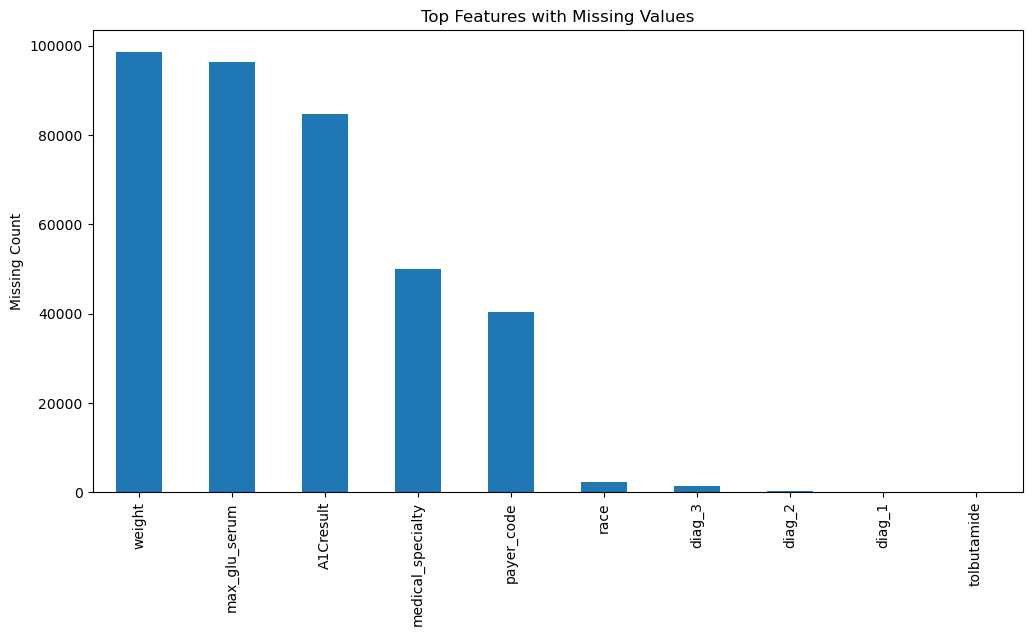

In [50]:
missing_counts = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_counts.head(10).plot(kind="bar")
plt.title("Top Features with Missing Values")
plt.ylabel("Missing Count")
plt.show()

Several variables contain large numbers of missing values. Features such as weight, max_glu_serum, and A1Cresult are missing for the majority of patients.

These variables may either require imputation or removal depending on their predictive usefulness and missingness proportion.

# Data Preprocessing

# Remove ID columns

In [53]:
# remove identifiers
df = df.drop(columns=["encounter_id", "patient_nbr"], errors="ignore")

df.shape

(101766, 48)

# Convert Target to Binary

In [54]:
df["readmitted_binary"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

df["readmitted_binary"].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [55]:
# drop orignal target 
df = df.drop(columns=["readmitted"])

# Handle Missing Values

In [56]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False).head(10)

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
tolbutamide           0.000000
dtype: float64

In [57]:
#drop very high missing columns
df = df.drop(columns=["weight","max_glu_serum","A1Cresult"])

Several variables contain large amounts of missing data.

The following features were removed because more than 80% of their values were missing:

- weight
- max_glu_serum
- A1Cresult

Features such as `medical_specialty` and `payer_code` were retained despite moderate missingness because they still contain useful information for a significant portion of the dataset.

Missing values in the remaining categorical features will be handled using imputation in later preprocessing steps.

# Fill Remaining Missing Values

In [59]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].fillna("Unknown")

# Separate Features and Target

In [60]:
X = df.drop(columns=["readmitted_binary"])
y = df["readmitted_binary"]

In [61]:
df.isnull().sum().sort_values(ascending=False).head()

race           0
glimepiride    0
glipizide      0
glyburide      0
tolbutamide    0
dtype: int64

# Define Feature Types

## Preprocessing Setup

Before training machine learning models, the dataset must be prepared in a structured way.

The feature set contains both:

- **numerical variables** such as hospital stay length and number of procedures
- **categorical variables** such as race, age group, medication status, and diagnosis codes

These two groups require different preprocessing steps:

- numerical features will be scaled
- categorical features will be one-hot encoded

In [62]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 11
Number of categorical features: 33

Numeric features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [63]:
# Import Preprocessing Tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Build Numerical Transformer

Numerical variables are scaled using `StandardScaler`.

Scaling is important because models such as logistic regression are sensitive to the scale of input variables. Standardization transforms each numeric feature so that it has mean 0 and standard deviation 1.

In [64]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Build Categorical Transformer

Categorical variables are converted into numerical format using **one-hot encoding**.

This creates binary indicator columns for each category so that machine learning models can process the categorical information.

In [66]:
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a ColumnTransformer

A `ColumnTransformer` allows us to apply different preprocessing steps to different groups of columns:

- scaling for numerical features
- one-hot encoding for categorical features

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEn...
                                  'diag_3', 'metformin', 'repaglinide',
                                  'nateglinide', 'chlorpropamide',
                                  'glimepiride', 'acetohexamide', 'glipizide',
                                  'glyburide', 'tolbutamide', 'pioglitazone',
                                  'rosiglitazone', 'acarbose', 'miglitol',
                                  'troglitazone', 'tolazamide', 'examide',
                                  'citoglipton', 'insulin',
                                  'glyburide-metformin', 'glipizide-metformin',
                                  'glimepiride-pioglitazone',
                                  'metformin-rosiglitazone', ...])])

# Train Test Split

The dataset is divided into training and testing sets.

- The **training set** is used to fit the model
- The **test set** is used to evaluate performance on unseen data

A **stratified split** is used so that the proportion of the target classes remains similar in both the training and test sets.

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (81412, 44)
X_test shape: (20354, 44)
y_train shape: (81412,)
y_test shape: (20354,)


# Check Target Balance After Split

In [69]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
readmitted_binary
0    0.888395
1    0.111605
Name: proportion, dtype: float64

Test target distribution:
readmitted_binary
0    0.888425
1    0.111575
Name: proportion, dtype: float64


The class proportions in the training and test sets remain very similar, confirming that stratified splitting preserved the target distribution.

# Fit Preprocessor on Training Data Only

To avoid data leakage, preprocessing should be learned from the training data only.

The fitted transformations are then applied to the test data.

In [70]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (81412, 2361)
Processed X_test shape: (20354, 2361)
